### TESS Exoplanet Detection and Classification

##### About the Dataset:

##### The dataset used in this project is based on **NASA’s TESS (Transiting Exoplanet Survey Satellite) mission** and contains information about **TESS Objects of Interest (TOIs)** identified during the search for potential exoplanets. The dataset contains **8,136 observations and 65 features**, covering object identification, stellar properties, planetary properties, transit characteristics, orbital parameters, and catalog metadata.

The main classification column,**(tfopwg_disp)**, represents the TFOPWG (TESS Follow-up Observing Program Working Group) disposition of each object. The dataset includes categories such as **PC (Planet Candidate), CP (Confirmed Planet), KP (Known Planet), FP (False Positive), FA (False Alarm), and APC (Ambiguous Planetary Candidate)**.

The dataset includes important astronomical features such as orbital period (`pl_orbper`), transit duration (`pl_trandurh`), transit depth (`pl_trandep`), planet radius (`pl_rade`), planetary insolation (`pl_insol`), equilibrium temperature (`pl_eqt`), stellar temperature (`st_teff`), stellar radius (`st_rad`), stellar surface gravity (`st_logg`), stellar brightness (`st_tmag`), and stellar distance (`st_dist`). Measurement uncertainty and limit/flag columns are also provided.

For the primary machine-learning task, these dispositions are transformed into a **binary classification target**, where PC, CP, and KP are grouped as the planetary/planet-candidate class, while FP and FA represent the false-signal class. APC observations are excluded from the primary binary model because their status is ambiguous.




In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# Loding the dataset

# NASA TOI CSV files can contain metadata/comment lines beginning with '#'.
df = pd.read_csv("TESS dataset.csv",comment='#')
df.head()

,toi,tid,tfopwg_disp,rastr,ra,decstr,dec,st_pmra,st_pmraerr1,st_pmraerr2,...,st_logg,st_loggerr1,st_loggerr2,st_logglim,st_rad,st_raderr1,st_raderr2,st_radlim,toi_created,rowupdate
0,1000.01,50365310,FP,07h29m25.85s,112.357708,-12d41m45.46s,-12.695960,-5.964,0.085,-0.085,...,4.19,0.07,-0.07,0,2.16986,0.072573,-0.072573,0,24-07-2019 15:58,09-09-2024 10:08
1,1001.01,88863718,PC,08h10m19.31s,122.580465,-05d30m49.87s,-5.513852,-4.956,0.102,-0.102,...,4.03,0.09,-0.09,0,2.01000,0.090000,-0.090000,0,24-07-2019 15:58,03-04-2023 14:31
2,1002.01,124709665,FP,06h58m54.47s,104.726966,-10d34m49.64s,-10.580455,-1.462,0.206,-0.206,...,NaN,NaN,NaN,0,5.73000,NaN,NaN,0,24-07-2019 15:58,11-07-2022 16:02
3,1003.01,106997505,FP,07h22m14.39s,110.559945,-25d12m25.26s,-25.207017,-0.939,0.041,-0.041,...,4.15,1.64,-1.64,0,NaN,NaN,NaN,0,24-07-2019 15:58,23-02-2022 10:10
4,1004.01,238597883,FP,08h08m42.77s,122.178195,-48d48m10.12s,-48.802811,-4.496,0.069,-0.069,...,4.14,0.07,-0.07,0,2.15000,0.060000,-0.060000,0,24-07-2019 15:58,09-09-2024 10:08


In [19]:
print("Shape:",df.shape)
print("="*50)
df.info()

Shape: (8136, 65)
<class 'pandas.DataFrame'>
RangeIndex: 8136 entries, 0 to 8135
Data columns (total 65 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   toi              8136 non-null   float64
 1   tid              8136 non-null   int64  
 2   tfopwg_disp      8134 non-null   str    
 3   rastr            8136 non-null   str    
 4   ra               8136 non-null   float64
 5   decstr           8136 non-null   str    
 6   dec              8136 non-null   float64
 7   st_pmra          8001 non-null   float64
 8   st_pmraerr1      8001 non-null   float64
 9   st_pmraerr2      8001 non-null   float64
 10  st_pmralim       8001 non-null   float64
 11  st_pmdec         8001 non-null   float64
 12  st_pmdecerr1     8001 non-null   float64
 13  st_pmdecerr2     8001 non-null   float64
 14  st_pmdeclim      8001 non-null   float64
 15  pl_tranmid       8136 non-null   float64
 16  pl_tranmiderr1   8124 non-null   float64
 17  pl_tran

In [20]:
df.describe()

,toi,tid,ra,dec,st_pmra,st_pmraerr1,st_pmraerr2,st_pmralim,st_pmdec,st_pmdecerr1,...,st_tefferr2,st_tefflim,st_logg,st_loggerr1,st_loggerr2,st_logglim,st_rad,st_raderr1,st_raderr2,st_radlim
count,8136.000000,8.136000e+03,8136.000000,8136.000000,8001.000000,8001.000000,8001.000000,8001.0,8001.000000,8001.000000,...,7633.000000,8136.0,7234.000000,5738.000000,5738.000000,8136.0,7508.000000,5972.000000,5972.000000,8136.0
mean,3955.176798,2.441331e+08,178.638461,-0.016684,-0.664568,0.232020,-0.232020,0.0,-8.925015,0.226107,...,-201.917602,0.0,4.304223,0.170815,-0.170815,0.0,1.401706,0.074356,-0.074356,0.0
std,2272.621966,1.610277e+08,103.216884,47.125774,75.223801,0.644809,0.644809,0.0,65.411805,0.636072,...,535.760941,0.0,0.303589,0.345751,0.345751,0.0,1.569306,0.081850,0.081850,0.0
min,101.010000,2.876000e+03,0.084680,-89.471513,-1624.050000,0.015000,-8.000000,0.0,-1230.620000,0.016000,...,-7000.000000,0.0,0.100000,0.000391,-2.010840,0.0,0.114827,0.003357,-1.723020,0.0
25%,1965.760000,1.293592e+08,95.814138,-43.366350,-10.536000,0.038000,-0.080000,0.0,-14.546000,0.038000,...,-157.000000,0.0,4.120000,0.080000,-0.091675,0.0,0.890000,0.050000,-0.080000,0.0
50%,3948.510000,2.457612e+08,158.187488,1.296760,-1.629000,0.051000,-0.051000,0.0,-3.419000,0.049000,...,-129.200000,0.0,4.330000,0.084277,-0.084277,0.0,1.238995,0.060000,-0.060000,0.0
75%,5923.260000,3.526843e+08,281.450622,42.504298,7.992000,0.080000,-0.038000,0.0,4.948000,0.071000,...,-122.000000,0.0,4.500000,0.091675,-0.080000,0.0,1.660000,0.080000,-0.050000,0.0
max,7921.010000,2.041563e+09,359.941195,89.086923,2074.520000,8.000000,-0.015000,0.0,1048.840000,8.000000,...,-4.400000,0.0,5.960650,2.010840,-0.000391,0.0,102.030000,1.723020,-0.003357,0.0


In [21]:
df.columns

Index(['toi', 'tid', 'tfopwg_disp', 'rastr', 'ra', 'decstr', 'dec', 'st_pmra',
       'st_pmraerr1', 'st_pmraerr2', 'st_pmralim', 'st_pmdec', 'st_pmdecerr1',
       'st_pmdecerr2', 'st_pmdeclim', 'pl_tranmid', 'pl_tranmiderr1',
       'pl_tranmiderr2', 'pl_tranmidlim', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_trandurh', 'pl_trandurherr1',
       'pl_trandurherr2', 'pl_trandurhlim', 'pl_trandep', 'pl_trandeperr1',
       'pl_trandeperr2', 'pl_trandeplim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_insol', 'pl_insolerr1', 'pl_insolerr2',
       'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim',
       'st_tmag', 'st_tmagerr1', 'st_tmagerr2', 'st_tmaglim', 'st_dist',
       'st_disterr1', 'st_disterr2', 'st_distlim', 'st_teff', 'st_tefferr1',
       'st_tefferr2', 'st_tefflim', 'st_logg', 'st_loggerr1', 'st_loggerr2',
       'st_logglim', 'st_rad', 'st_raderr1', 'st_raderr2', 'st_radlim',
       'toi_created', 'rowupda

### Data Cleaning and Preprocessing:

In [22]:
print("Duplicate Rows:",df.duplicated().sum())

Duplicate Rows: 0


In [23]:
print(df.dtypes)

toi            float64
tid              int64
tfopwg_disp        str
rastr              str
ra             float64
                ...   
st_raderr1     float64
st_raderr2     float64
st_radlim        int64
toi_created        str
rowupdate          str
Length: 65, dtype: object


#### Feature Selection:

In [24]:
# Identify the target and remove irrelevant column

target = 'tfopwg_disp'

X = df.drop(columns=[target])
Y = df[target]

print("Target column:", target)
print("Feature columns:", X.shape[1])

Target column: tfopwg_disp
Feature columns: 64


#### Remove identifier and administrative columns

These columns identify records or indicate when the data was updated. They generally should not be used as predictive features.

('toi':	Object/record identifier,
'tid':	Target/record identifier,
'toi_created':	Administrative/date information,
'rowupdate':	Database update information.)

In [25]:
# Identifier / administrative columns
id_columns = [
    'toi',
    'tid',
    'toi_created',
    'rowupdate'
]

X = X.drop(columns=id_columns, errors='ignore')

print("Columns after removing identifiers:")
print(X.columns.tolist())

print("\nNumber of features:", X.shape[1])

Columns after removing identifiers:
['rastr', 'ra', 'decstr', 'dec', 'st_pmra', 'st_pmraerr1', 'st_pmraerr2', 'st_pmralim', 'st_pmdec', 'st_pmdecerr1', 'st_pmdecerr2', 'st_pmdeclim', 'pl_tranmid', 'pl_tranmiderr1', 'pl_tranmiderr2', 'pl_tranmidlim', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_trandurh', 'pl_trandurherr1', 'pl_trandurherr2', 'pl_trandurhlim', 'pl_trandep', 'pl_trandeperr1', 'pl_trandeperr2', 'pl_trandeplim', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_insol', 'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'st_tmag', 'st_tmagerr1', 'st_tmagerr2', 'st_tmaglim', 'st_dist', 'st_disterr1', 'st_disterr2', 'st_distlim', 'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_logg', 'st_loggerr1', 'st_loggerr2', 'st_logglim', 'st_rad', 'st_raderr1', 'st_raderr2', 'st_radlim']

Number of features: 60


#### Separate useful physical features from error/limit columns

This TOI dataset contains many columns such as:

pl_rade
pl_radeerr1
pl_radeerr2
pl_radelim

Here, pl_rade is the estimated planet radius, while err1, err2, and lim describe uncertainty or limits.

For a simpler and more interpretable model, initially exclude the uncertainty and limit columns.

In [26]:
# Remove uncertainty and limit columns
error_limit_columns = [
    col for col in X.columns
    if 'err' in col.lower() or 'lim' in col.lower()
]

X = X.drop(columns=error_limit_columns)

print("Removed error/limit columns:")
print(error_limit_columns)

print("\nRemaining features:")
print(X.columns.tolist())

print("\nNumber of remaining features:", X.shape[1])

Removed error/limit columns:
['st_pmraerr1', 'st_pmraerr2', 'st_pmralim', 'st_pmdecerr1', 'st_pmdecerr2', 'st_pmdeclim', 'pl_tranmiderr1', 'pl_tranmiderr2', 'pl_tranmidlim', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_trandurherr1', 'pl_trandurherr2', 'pl_trandurhlim', 'pl_trandeperr1', 'pl_trandeperr2', 'pl_trandeplim', 'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'st_tmagerr1', 'st_tmagerr2', 'st_tmaglim', 'st_disterr1', 'st_disterr2', 'st_distlim', 'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_loggerr1', 'st_loggerr2', 'st_logglim', 'st_raderr1', 'st_raderr2', 'st_radlim']

Remaining features:
['rastr', 'ra', 'decstr', 'dec', 'st_pmra', 'st_pmdec', 'pl_tranmid', 'pl_orbper', 'pl_trandurh', 'pl_trandep', 'pl_rade', 'pl_insol', 'pl_eqt', 'st_tmag', 'st_dist', 'st_teff', 'st_logg', 'st_rad']

Number of remaining features: 18


In [27]:
# Select numerical columns only

X_numeric = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32'])

print("Number of numerical features:", X_numeric.shape[1])
print("\nNumerical features:")
print(X_numeric.columns.tolist())

Number of numerical features: 16

Numerical features:
['ra', 'dec', 'st_pmra', 'st_pmdec', 'pl_tranmid', 'pl_orbper', 'pl_trandurh', 'pl_trandep', 'pl_rade', 'pl_insol', 'pl_eqt', 'st_tmag', 'st_dist', 'st_teff', 'st_logg', 'st_rad']


In [28]:
# Calculate missing percentage

missing_percentage = X_numeric.isnull().mean() * 100

missing_table = pd.DataFrame({
    'Feature': missing_percentage.index,
    'Missing_Percentage': missing_percentage.values
}).sort_values(
    by='Missing_Percentage',
    ascending=False
)

print(missing_table)

        Feature  Missing_Percentage
14      st_logg           11.086529
15       st_rad            7.718781
8       pl_rade            6.403638
10       pl_eqt            3.945428
12      st_dist            2.740905
9      pl_insol            2.298427
13      st_teff            2.150934
3      st_pmdec            1.659292
2       st_pmra            1.659292
5     pl_orbper            1.364307
6   pl_trandurh            0.049164
0            ra            0.000000
7    pl_trandep            0.000000
4    pl_tranmid            0.000000
1           dec            0.000000
11      st_tmag            0.000000


#### Remove features with excessive missing values:

In [29]:
# Keep features with less than 50% missing values

valid_columns = missing_percentage[
    missing_percentage < 50
].index

X_clean = X_numeric[valid_columns]

print("Features after missing-value filtering:", X_clean.shape[1])

Features after missing-value filtering: 16


In [30]:
# Fill remaining missing values

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_imputed = pd.DataFrame(
    imputer.fit_transform(X_clean),
    columns=X_clean.columns,
    index=X_clean.index
)

print("Missing values after imputation:")
print(X_imputed.isnull().sum().sum())

Missing values after imputation:
0


#### Remove highly correlated features:


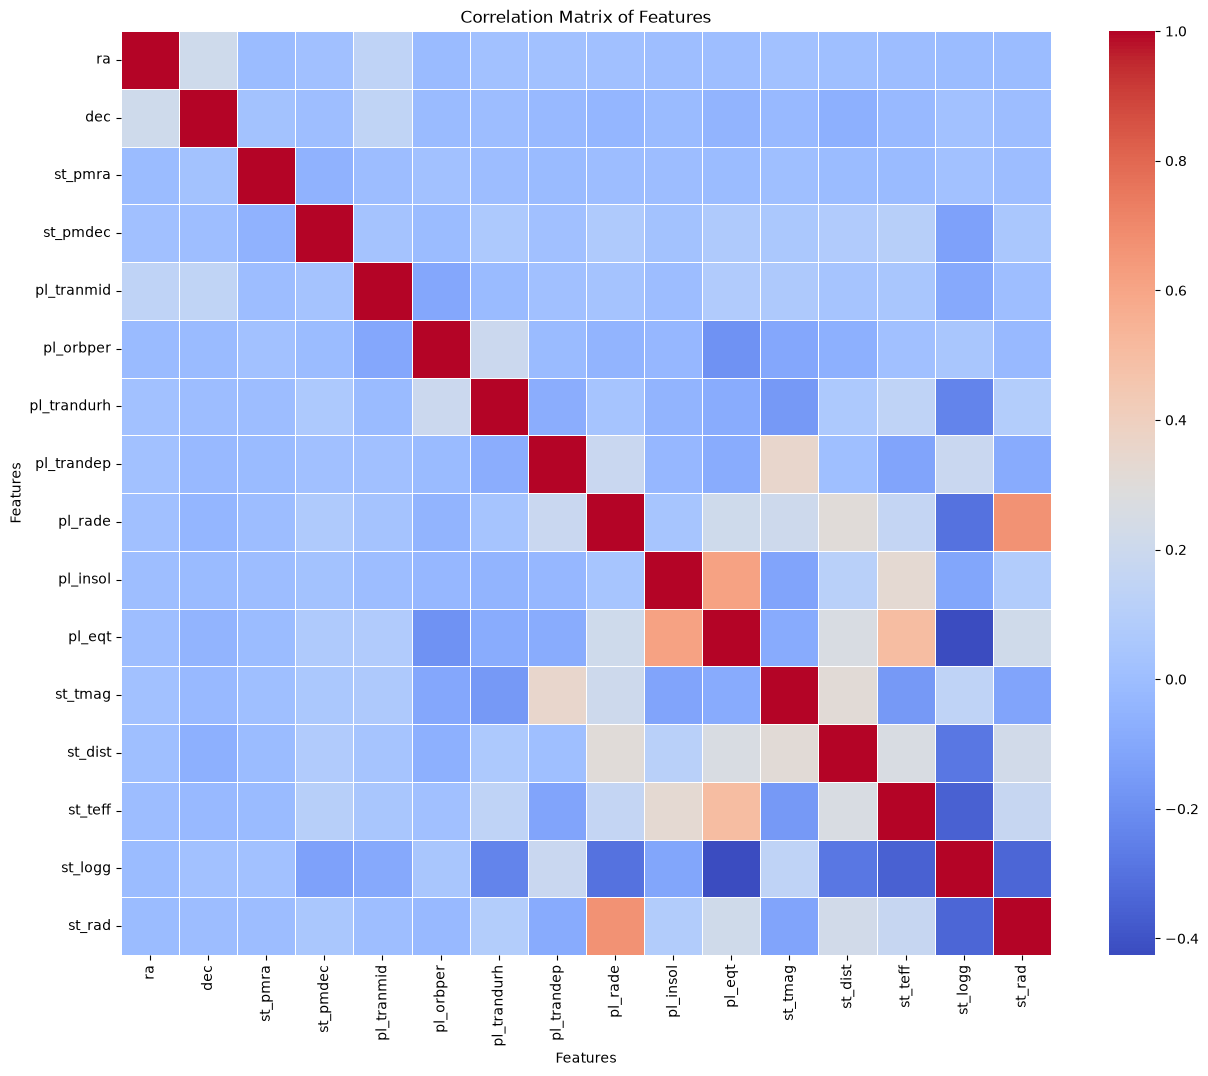

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# For correlation matrix
corr_matrix = X_imputed.corr()

plt.figure(figsize=(15, 12))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Matrix of Features")
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()

In [32]:
# Calculate absolute correlation matrix

corr_matrix = X_imputed.corr().abs()

# Select upper triangle

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find highly correlated columns

high_corr_columns = [
    column
    for column in upper.columns
    if any(upper[column] > 0.90)
]

print("Highly correlated features:")
print(high_corr_columns)

Highly correlated features:
[]


In [33]:
# Remove highly correlated columns

X_reduced = X_imputed.drop(
    columns=high_corr_columns
)

print("Features after correlation filtering:", X_reduced.shape[1])

Features after correlation filtering: 16


Used a correlation threshold of 0.90 to identify redundant features. When two features are highly correlated, they provide similar information. Removing one of them reduces redundancy and helps the model work with a more independent set of features.

In [34]:
print(X_reduced.info())

<class 'pandas.DataFrame'>
RangeIndex: 8136 entries, 0 to 8135
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ra           8136 non-null   float64
 1   dec          8136 non-null   float64
 2   st_pmra      8136 non-null   float64
 3   st_pmdec     8136 non-null   float64
 4   pl_tranmid   8136 non-null   float64
 5   pl_orbper    8136 non-null   float64
 6   pl_trandurh  8136 non-null   float64
 7   pl_trandep   8136 non-null   float64
 8   pl_rade      8136 non-null   float64
 9   pl_insol     8136 non-null   float64
 10  pl_eqt       8136 non-null   float64
 11  st_tmag      8136 non-null   float64
 12  st_dist      8136 non-null   float64
 13  st_teff      8136 non-null   float64
 14  st_logg      8136 non-null   float64
 15  st_rad       8136 non-null   float64
dtypes: float64(16)
memory usage: 1017.1 KB
None


| Column                   |  Meaning                                                                                                                |
| ------------------------ | ---------------------------------------------------------------------------------------------------------------------------------------- |
| **`ra`**                 | **Right Ascension** — the position of the star in the sky, similar to longitude on Earth.                                                |
| **`dec`**                | **Declination** — the position of the star north or south in the sky, similar to latitude on Earth.                                      |
| **`st_pmra`**            | Star's **proper motion in Right Ascension** — how the star appears to move across the sky in that direction.                             |
| **`st_pmdec`**           | Star's **proper motion in Declination** — how the star appears to move across the sky in that direction.                                 |
| **`pl_tranmid`**         | **Transit midpoint time** — the time at which the planet is approximately in the middle of its transit across the star.                  |
| **`pl_orbper`**          | **Orbital period** — how long the planet takes to complete one orbit around its star.                                                    |
| **`pl_trandep`**         | **Transit depth** — how much the star's brightness decreases when the planet passes in front of it.                                      |
| **`pl_rade`**            | **Planet radius** — estimated radius of the planet, generally expressed relative to Earth.                                               |
| **`pl_insol`**           | **Planetary insolation** — amount of stellar energy received by the planet compared with Earth.                                          |
| **`pl_eqt`**             | **Equilibrium temperature** — estimated temperature of the planet based mainly on the energy received from its star.                     |
| **`st_tmag`**            | **TESS magnitude** — brightness of the star as measured in the TESS observation system. Lower magnitude generally means a brighter star. |
| **`st_dist`**            | **Stellar distance** — distance between Earth and the star, usually measured in parsecs.                                                 |
| **`st_teff`**            | **Stellar effective temperature** — temperature representing the star's surface radiation, measured in Kelvin.                           |
| **`st_logg`**            | **Stellar surface gravity** — a measure of the gravitational acceleration at the star's surface.                                         |
| **`st_rad`**             | **Stellar radius** — estimated size/radius of the star, usually relative to the Sun.                                                   |


In [35]:
Y.value_counts()

tfopwg_disp
PC     4915
FP     1280
CP      748
KP      607
APC     484
FA      100
Name: count, dtype: int64

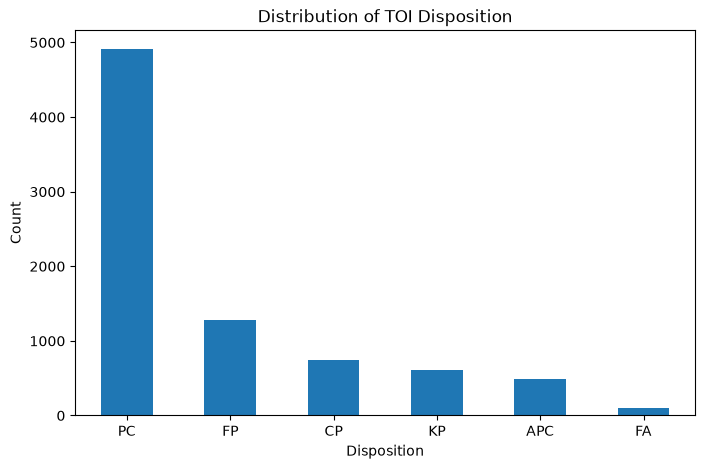

In [36]:
Y.value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribution of TOI Disposition")
plt.xlabel("Disposition")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [37]:
Y.info()

<class 'pandas.Series'>
RangeIndex: 8136 entries, 0 to 8135
Series name: tfopwg_disp
Non-Null Count  Dtype
--------------  -----
8134 non-null   str  
dtypes: str(1)
memory usage: 63.7 KB


In [38]:
# Remove the rows with target missing

valid_rows = Y.notna()

X_clean = X_reduced.loc[valid_rows].copy()
y_clean = Y.loc[valid_rows].copy()


In [39]:
# Encode target classes

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y_clean)


#### Select the most useful features:

In [40]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
# Because 'tfopwg_disp' is a classification target, we can use Mutual Information.

# Select top 15 features
k = 15

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=k
)

X_selected = selector.fit_transform(
    X_clean,
    y_encoded
)

# Get selected feature names
selected_features = X_clean.columns[selector.get_support()]

print("Selected features:")
print(selected_features.tolist())

print("\nNumber of selected features:", len(selected_features))

Selected features:
['ra', 'dec', 'st_pmra', 'st_pmdec', 'pl_tranmid', 'pl_orbper', 'pl_trandep', 'pl_rade', 'pl_insol', 'pl_eqt', 'st_tmag', 'st_dist', 'st_teff', 'st_logg', 'st_rad']

Number of selected features: 15


In [41]:
# For features and Target Columns

x = selected_features
Target = y_encoded

x = pd.DataFrame(
    X_selected,
    columns=selected_features,
    index=X_clean.index
)

print("Features shape:",x.shape)
print("\nFeatures data type:")
print(x.dtypes)
print("="*75)
Target = pd.Series(Target, name="tfopwg_disp")

print("\nTarget shape:")
print(Target.shape)

print("\nTarget data type:")
print(Target.dtype)

Features shape: (8134, 15)

Features data type:
ra            float64
dec           float64
st_pmra       float64
st_pmdec      float64
pl_tranmid    float64
pl_orbper     float64
pl_trandep    float64
pl_rade       float64
pl_insol      float64
pl_eqt        float64
st_tmag       float64
st_dist       float64
st_teff       float64
st_logg       float64
st_rad        float64
dtype: object

Target shape:
(8134,)

Target data type:
int64


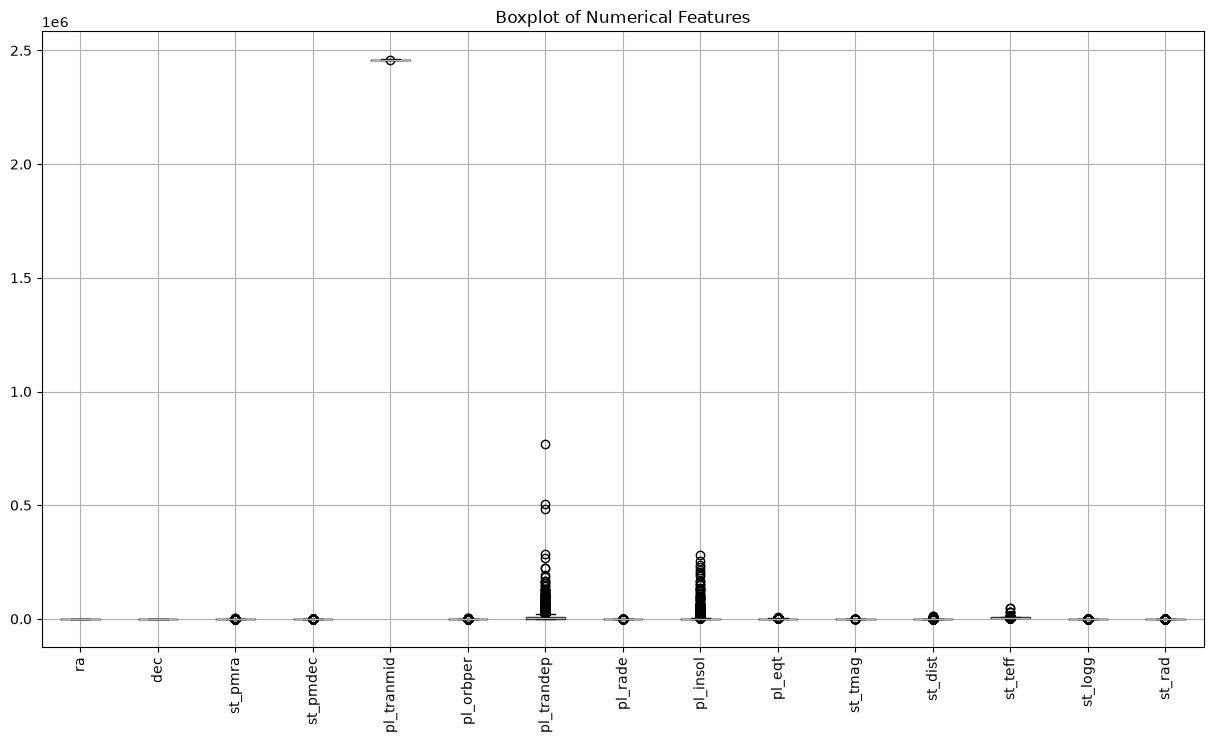

In [42]:
# For outlier detection

plt.figure(figsize=(15, 8))

x.boxplot()

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=90)
plt.show()

Feature set shape: (8134, 15)
Number of features: 15
Number of samples: 8134
Outliers capped using IQR method.


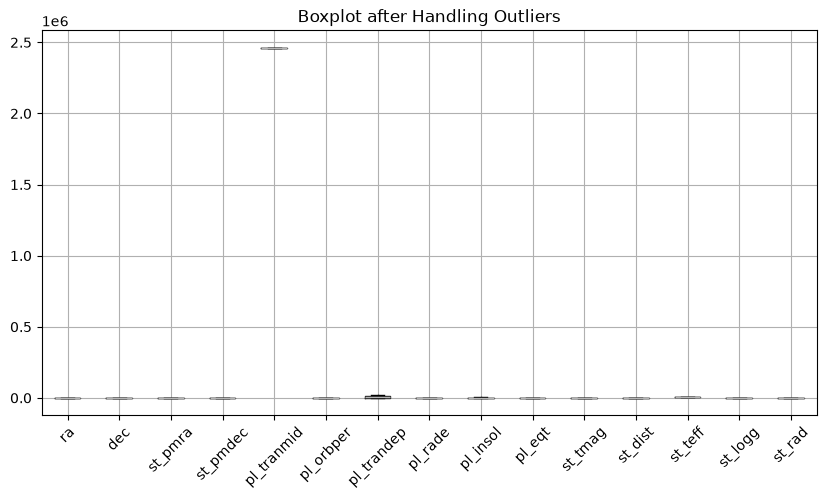

In [43]:
# For handling outliers:

for col in x.select_dtypes(include=np.number).columns:

    Q1 = x[col].quantile(0.25)
    Q3 = x[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    x[col] = x[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Feature set shape:", x.shape)
print("Number of features:", x.shape[1])
print("Number of samples:", x.shape[0])

print('='*75)
print("Outliers capped using IQR method.")
print('='*75)

plt.figure(figsize=(10, 5))
x.boxplot()
plt.title("Boxplot after Handling Outliers")
plt.xticks(rotation=45)
plt.show()


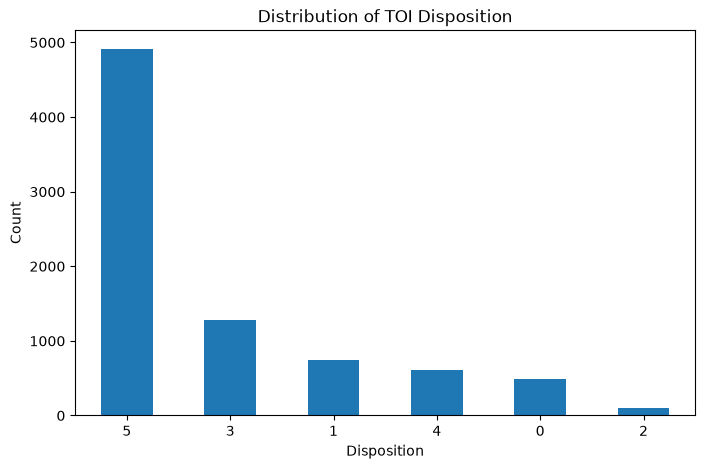

In [44]:
Target.value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribution of TOI Disposition")
plt.xlabel("Disposition")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

#### Create Binary Target:

#### Planetary / Planet-Candidate side = 1
#### False-signal side = 0
#### APC = ambiguous → excluded


In [45]:
# Create Binary Target

binary_mapping = {
    "PC": 1,
    "CP": 1,
    "KP": 1,
    "FP": 0,
    "FA": 0
}

df["binary_target"] = df["tfopwg_disp"].map(binary_mapping)

# Remove unmapped/missing target rows
df = df.dropna(subset=["binary_target"]).copy()

# Convert to integer
df["binary_target"] = df["binary_target"].astype(int)

# Final target
y = df["binary_target"]


print("\nBinary Target Distribution:")
print("="*75)
print(y.value_counts())


Binary Target Distribution:
binary_target
1    6270
0    1380
Name: count, dtype: int64


In [46]:
y.shape

(7650,)

In [47]:
# Align x and y using the same rows
common_index = x.index.intersection(y.index)

x = x.loc[common_index]
y = y.loc[common_index]

print("X shape:", x.shape)
print("y shape:", y.shape)

X shape: (7650, 15)
y shape: (7650,)


#### EDA:

In [48]:
print(df["binary_target"].value_counts())
print(df["binary_target"].value_counts(normalize=True) * 100)

binary_target
1    6270
0    1380
Name: count, dtype: int64
binary_target
1    81.960784
0    18.039216
Name: proportion, dtype: float64


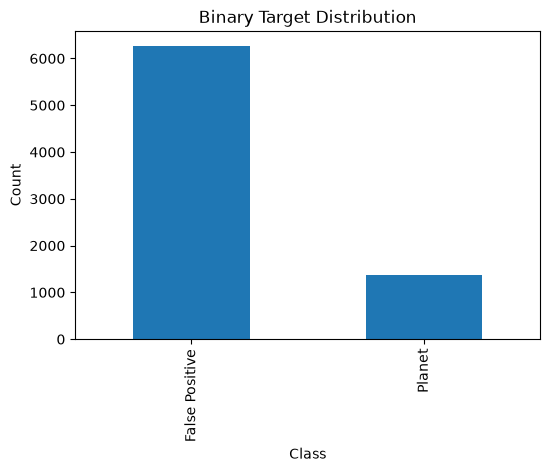

In [49]:
df["binary_target"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Binary Target Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks([0, 1], ["False Positive", "Planet"])
plt.show()

**Observation:**

> The binary target distribution shows a significant class imbalance, with False Positive observations substantially outnumbering Planet observations.  This means the model may become biased toward predicting the 'False Positive' class because it has much more training data.

In [50]:
x.describe().T

,count,mean,std,min,25%,50%,75%,max
ra,7650.0,1.790832e+02,103.036549,8.468000e-02,9.639126e+01,1.590967e+02,2.815510e+02,3.599412e+02
dec,7650.0,1.543102e-01,47.415849,-8.947151e+01,-4.367371e+01,1.814049e+00,4.290332e+01,8.908692e+01
st_pmra,7650.0,-1.391669e+00,18.802730,-3.722250e+01,-1.028100e+01,-1.629000e+00,7.740000e+00,3.472350e+01
st_pmdec,7650.0,-5.196397e+00,19.484633,-4.273675e+01,-1.444700e+01,-3.419000e+00,4.816500e+00,3.326125e+01
pl_tranmid,7650.0,2.459648e+06,676.733880,2.457938e+06,2.459223e+06,2.459667e+06,2.460090e+06,2.461129e+06
pl_orbper,7650.0,6.012641e+00,4.795425,1.638211e-01,2.633872e+00,4.141980e+00,8.090584e+00,1.629507e+01
pl_trandep,7650.0,6.899340e+03,6661.782031,2.458349e+01,1.405976e+03,4.695776e+03,1.028825e+04,2.361482e+04
pl_rade,7650.0,9.937873e+00,5.601712,5.525072e-01,4.792071e+00,1.050271e+01,1.354715e+01,2.661962e+01
pl_insol,7650.0,7.974253e+02,940.623827,3.419000e-04,9.042375e+01,3.774433e+02,1.150057e+03,2.813779e+03
pl_eqt,7650.0,1.257935e+03,580.933831,3.700000e+01,8.348825e+02,1.193000e+03,1.581560e+03,2.703652e+03


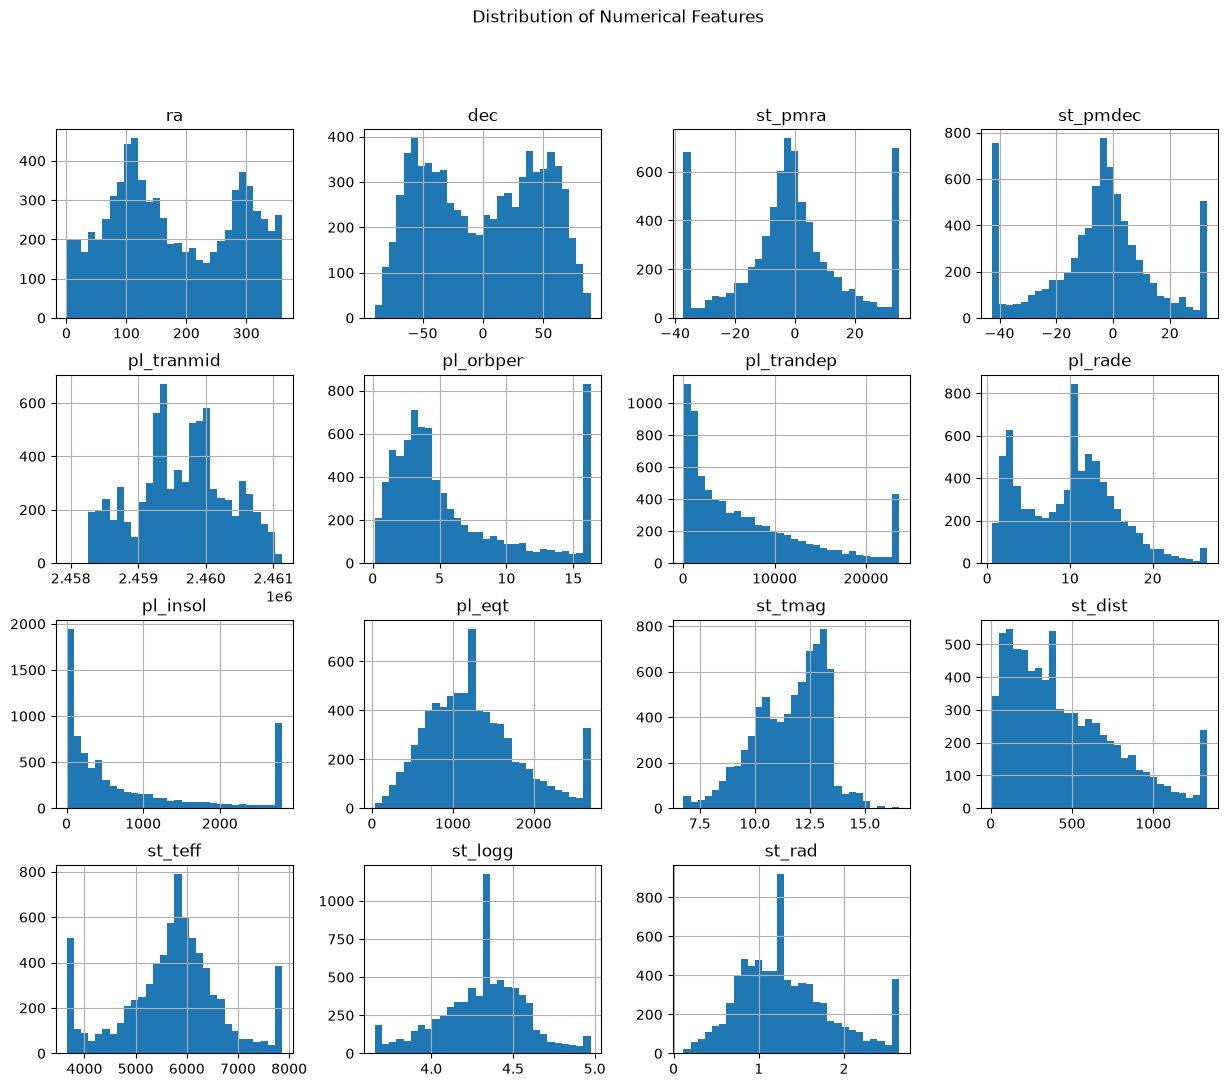

In [51]:
x.hist(
    figsize=(15, 12),
    bins=30
)

plt.suptitle("Distribution of Numerical Features")
plt.show()

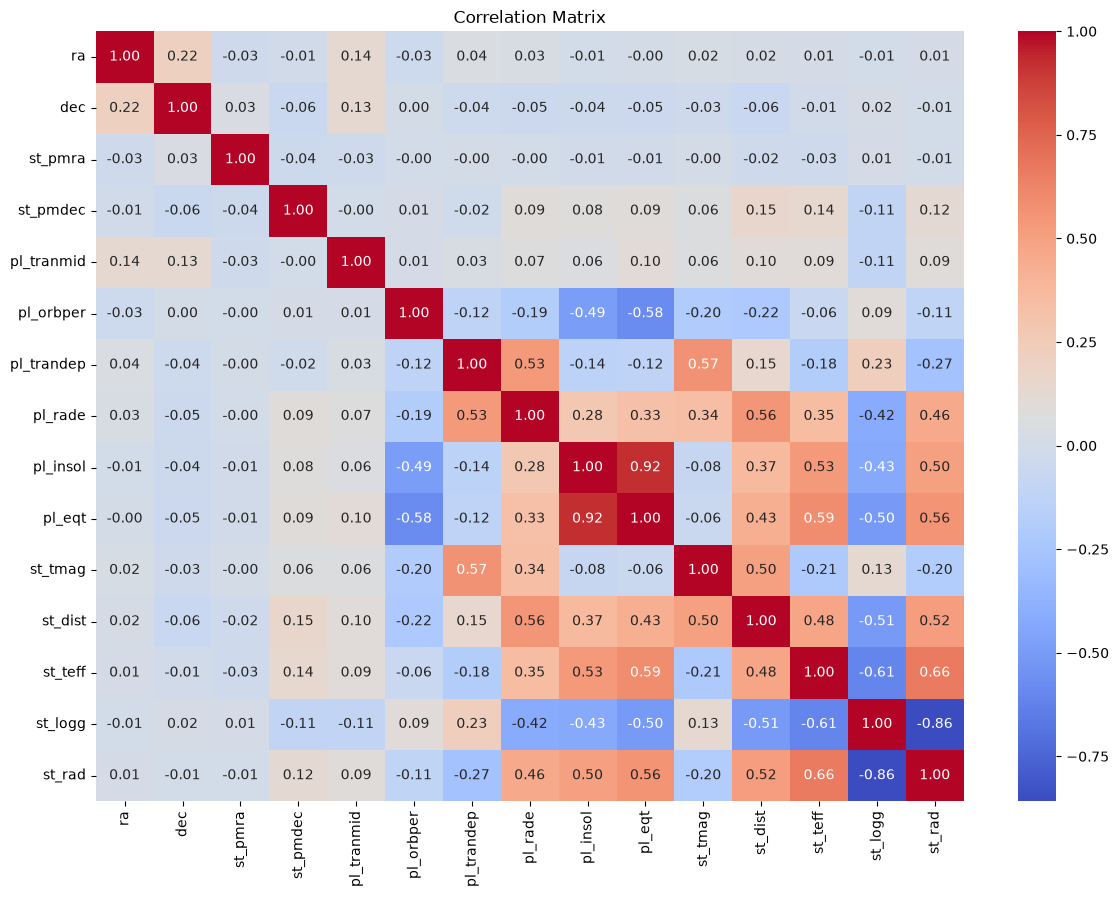

In [52]:
# Correlation Matrix

corr_matrix = x.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

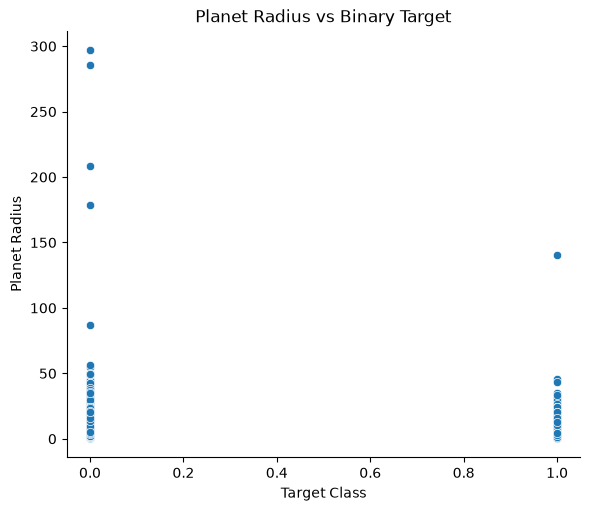

In [53]:
# To find relation between features and Target

sns.relplot(
    data=df,
    x="binary_target",
    y="pl_rade",
    kind="scatter",
    height=5,
    aspect=1.2
)

plt.title("Planet Radius vs Binary Target")
plt.xlabel("Target Class")
plt.ylabel("Planet Radius")
plt.show()

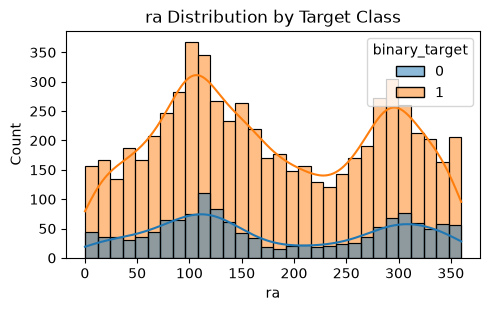

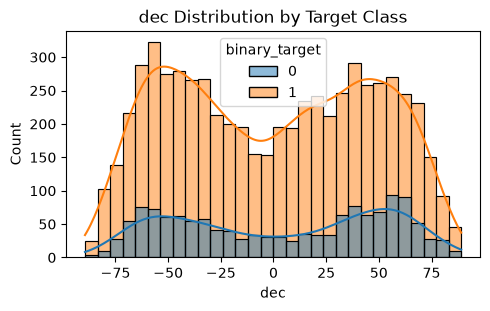

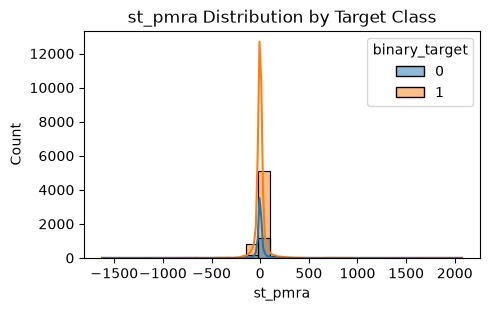

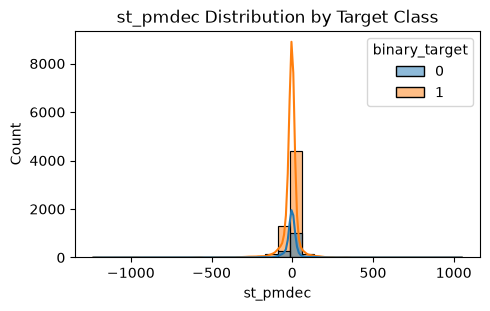

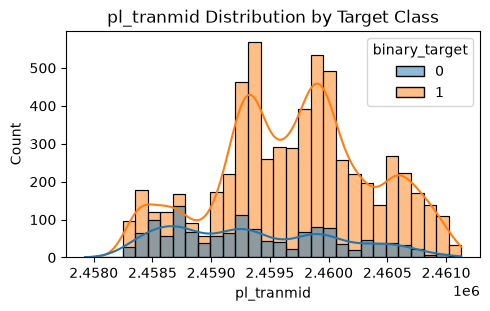

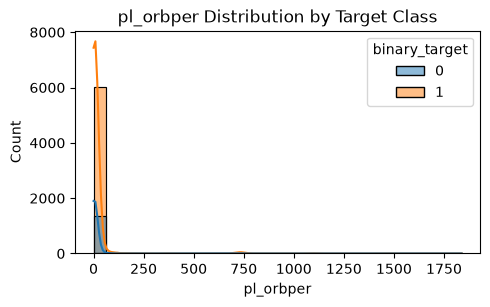

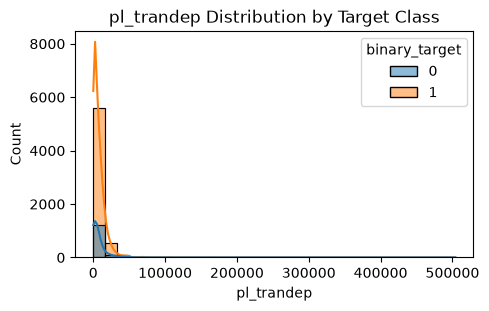

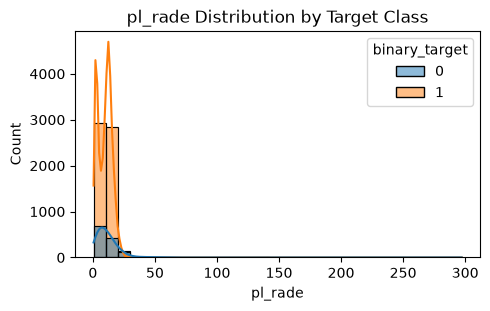

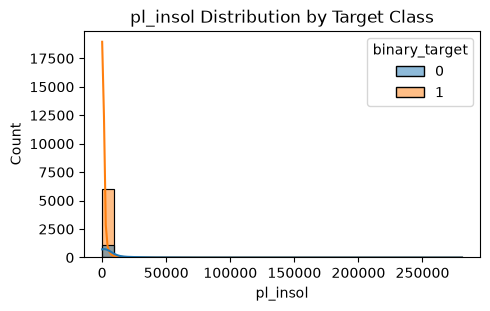

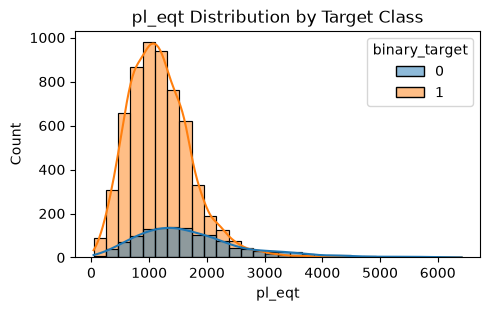

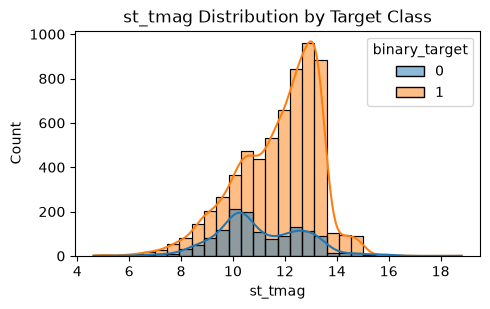

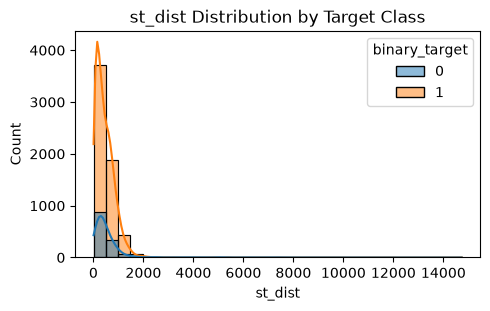

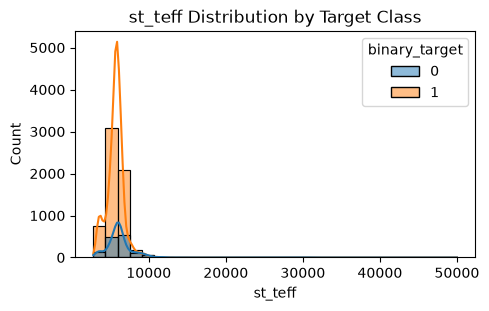

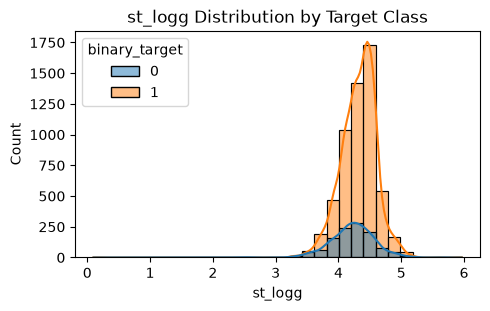

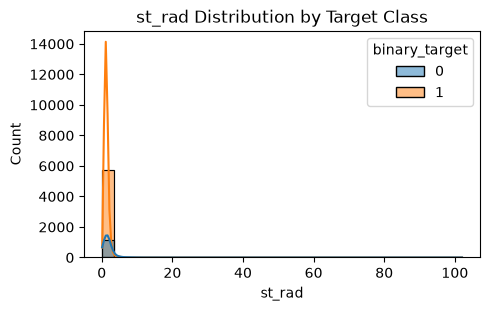

In [54]:
# Compaire feature distribution by classes
for feature in x:
    plt.figure(figsize=(5, 3))

    sns.histplot(
        data=df,
        x=feature,
        hue="binary_target",
        kde=True,
        bins=30
    )

    plt.tight_layout()
    plt.title(f"{feature} Distribution by Target Class")
    plt.show()

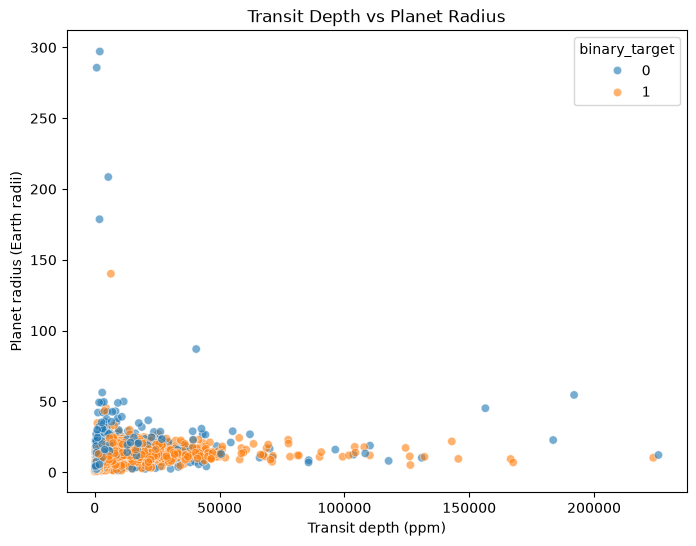

In [55]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="pl_trandep",
    y="pl_rade",
    hue="binary_target",
    alpha=0.6
)
plt.title("Transit Depth vs Planet Radius")
plt.xlabel("Transit depth (ppm)")
plt.ylabel("Planet radius (Earth radii)")
plt.show()


#### Observations:
The dataset contains 8,136 TOI observations.
The original dataset contains 65 columns.
Several columns contain missing values and require appropriate handling.
Identifier and administrative columns are not suitable as predictive features.
The target 'tfopwg_disp' contains multiple disposition categories.
The classification target was converted into a binary target.
Numerical features have different scales and distributions.
Some features may contain extreme values that require investigation rather than automatic removal.
Correlation analysis helps identify redundant features.
The EDA results guide subsequent feature selection, preprocessing, and model development.

### Feature Engineering:

stellar_luminosity:
The approximate amount of energy/light produced by the host star.
Luminosity ∝ Radius² × Temperature⁴

stellar_surface_area:
The approximate surface area of the host star.

transit_signal:
The approximate strength of the signal produced when a planet passes in front of its star.
Transit depth ≈ (Planet radius / Star radius)²

In [56]:
X_fe = x.copy()

print("Original shape:", X_fe.shape)
print("Original features:")
print(X_fe.columns.tolist())

# 1. Stellar luminosity-related feature
# Based on stellar radius and effective temperature

X_fe["stellar_luminosity"] = (
    X_fe["st_rad"] ** 2 *
    (X_fe["st_teff"] / 5778) ** 4
)

# 2. Approximate stellar surface area

X_fe["stellar_surface_area"] = X_fe["st_rad"] ** 2

# 3. Transit-related feature
# Approximate relative transit signal using transit depth

X_fe["transit_signal"] = X_fe["pl_trandep"]

print('='*75)
print("New shape:", X_fe.shape)
print("Features after engineering:")
print(X_fe.columns.tolist())

Original shape: (7650, 15)
Original features:
['ra', 'dec', 'st_pmra', 'st_pmdec', 'pl_tranmid', 'pl_orbper', 'pl_trandep', 'pl_rade', 'pl_insol', 'pl_eqt', 'st_tmag', 'st_dist', 'st_teff', 'st_logg', 'st_rad']
New shape: (7650, 18)
Features after engineering:
['ra', 'dec', 'st_pmra', 'st_pmdec', 'pl_tranmid', 'pl_orbper', 'pl_trandep', 'pl_rade', 'pl_insol', 'pl_eqt', 'st_tmag', 'st_dist', 'st_teff', 'st_logg', 'st_rad', 'stellar_luminosity', 'stellar_surface_area', 'transit_signal']


In [57]:
# Cheking newly created features

print(X_fe[[
    "stellar_luminosity",
    "stellar_surface_area",
    "transit_signal"
]].describe())

       stellar_luminosity  stellar_surface_area  transit_signal
count         7650.000000           7650.000000     7650.000000
mean             2.985893              2.024430     6899.339749
std              4.028562              1.692520     6661.782031
min              0.002605              0.013185       24.583493
25%              0.607200              0.828100     1405.975630
50%              1.571850              1.535109     4695.776234
75%              3.658791              2.590973    10288.250000
max             24.012739              6.999398    23614.819563


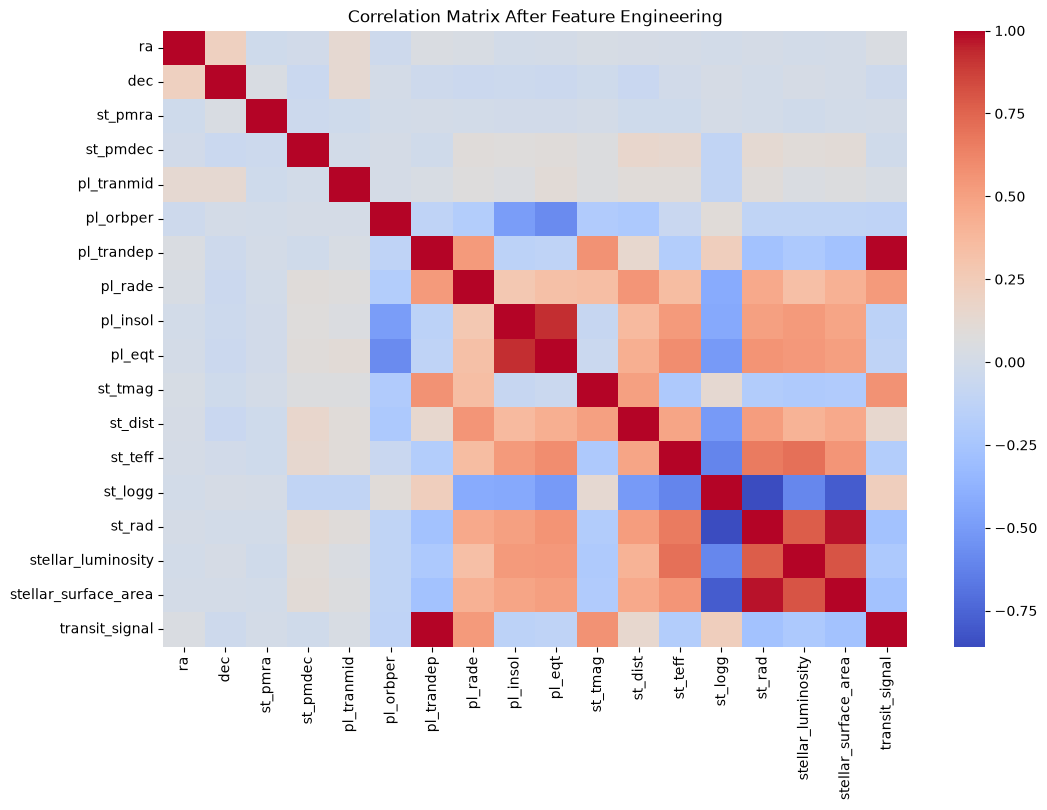

In [58]:
# For correlation matrix of newly created features

plt.figure(figsize=(12, 8))

sns.heatmap(
    X_fe.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix After Feature Engineering")
plt.show()

#### Observation:
>Strong correlation exists between 'pl_insol' and 'pl_eqt'.

>'st_teff' and 'st_rad' are positively correlated.

>'st_logg' is negatively correlated with several stellar features.

>'stellar_luminosity' and 'stellar_surface_area' show redundancy with existing stellar features.

>'transit_signal' is highly correlated with 'pl_trandep', so it is redundant.

>Most positional features show weak correlations.

In [59]:
# 'stellar_surface_area' is redundant with 'st_rad'.
# 'transit_signal' is redundant with 'pl_trandep'.
# 'stellar_luminosity' is strongly related to 'st_rad' and 'st_teff'.

# Remove redundant engineered features

X_fe = X_fe.drop(
    columns=["stellar_surface_area", "transit_signal"]
)

print("Final feature shape:", X_fe.shape)
print("Final features:")
print(X_fe.columns.tolist())

Final feature shape: (7650, 16)
Final features:
['ra', 'dec', 'st_pmra', 'st_pmdec', 'pl_tranmid', 'pl_orbper', 'pl_trandep', 'pl_rade', 'pl_insol', 'pl_eqt', 'st_tmag', 'st_dist', 'st_teff', 'st_logg', 'st_rad', 'stellar_luminosity']


 **`stellar_luminosity`** | **Engineered feature** — an estimate related to the star's luminosity, calculated using `st_rad` and `st_teff`.

### Training and Testing:

In [60]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Shape: (6120, 15)
Testing Shape: (1530, 15)
Training Target Shape: (6120,)
Testing Target Shape: (1530,)


### Feature Scaling:

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Scaled training shape:", x_train_scaled.shape)
print("Scaled testing shape:", x_test_scaled.shape)

Scaled training shape: (6120, 15)
Scaled testing shape: (1530, 15)


### Training the Model and Evaluating.

### Train Multiple Classification Models

> 1. Logistic Regression
> 2. Decision Tree
> 3. Random Forest
> 4. K-Nearest Neighbors
> 5. Support Vector Machine

In [62]:
# 1. Logistic Regression
# Model Training

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(x_train_scaled, y_train)

lr_pred = lr_model.predict(x_test_scaled)

print("Logistic Regression model trained successfully.")

# Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

# Classification Report

from sklearn.metrics import classification_report

print('='*80)
print(classification_report(
    y_test,
    lr_pred,
    target_names=["False Signal", "Planet"]
))

Logistic Regression model trained successfully.
Accuracy : 0.8352941176470589
Precision: 0.8469529085872576
Recall   : 0.9752791068580542
F1 Score : 0.9065974796145293
              precision    recall  f1-score   support

False Signal       0.64      0.20      0.30       276
      Planet       0.85      0.98      0.91      1254

    accuracy                           0.84      1530
   macro avg       0.74      0.59      0.61      1530
weighted avg       0.81      0.84      0.80      1530



In [63]:
# 2. Decisin Tree

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(x_train, y_train)

dt_pred = dt_model.predict(x_test)

print("Decision Tree model trained successfully.")

# Model Evaluation

print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))

# Classification Report

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    dt_pred,
    target_names=["False Signal", "Planet"]
))

Decision Tree model trained successfully.
Accuracy : 0.7986928104575164
Precision: 0.8736176935229067
Recall   : 0.8819776714513556
F1 Score : 0.8777777777777778
              precision    recall  f1-score   support

False Signal       0.44      0.42      0.43       276
      Planet       0.87      0.88      0.88      1254

    accuracy                           0.80      1530
   macro avg       0.66      0.65      0.65      1530
weighted avg       0.80      0.80      0.80      1530



In [64]:
# 3. Random Forest
# Model Training

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)

print("Random Forest model trained successfully.")

#Model Evaluation

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

# Classification Report

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred,
    target_names=["False Signal", "Planet"]
))

Random Forest model trained successfully.
Accuracy : 0.8581699346405228
Precision: 0.8732901367890569
Recall   : 0.967304625199362
F1 Score : 0.917896329928112
              precision    recall  f1-score   support

False Signal       0.71      0.36      0.48       276
      Planet       0.87      0.97      0.92      1254

    accuracy                           0.86      1530
   macro avg       0.79      0.66      0.70      1530
weighted avg       0.84      0.86      0.84      1530



In [65]:
# 4. K-Nearest Neighbors (KNN)
# Model Training

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(x_train_scaled, y_train)

knn_pred = knn_model.predict(x_test_scaled)

print("KNN model trained successfully.")

# Model Evaluation

print("Accuracy :", accuracy_score(y_test, knn_pred))
print("Precision:", precision_score(y_test, knn_pred))
print("Recall   :", recall_score(y_test, knn_pred))
print("F1 Score :", f1_score(y_test, knn_pred))

# Confusion Matrix

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    knn_pred,
    target_names=["False Signal", "Planet"]
))

KNN model trained successfully.
Accuracy : 0.8372549019607843
Precision: 0.8556263269639066
Recall   : 0.9641148325358851
F1 Score : 0.906636670416198
              precision    recall  f1-score   support

False Signal       0.62      0.26      0.37       276
      Planet       0.86      0.96      0.91      1254

    accuracy                           0.84      1530
   macro avg       0.74      0.61      0.64      1530
weighted avg       0.81      0.84      0.81      1530



In [66]:
# 5. Support Vector Machine (SVM)
# Model Training

from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(x_train_scaled, y_train)

svm_pred = svm_model.predict(x_test_scaled)

print("SVM model trained successfully.")

# Model Evaluation

print("Accuracy :", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall   :", recall_score(y_test, svm_pred))
print("F1 Score :", f1_score(y_test, svm_pred))

# Confusion Matrix
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    svm_pred,
    target_names=["False Signal", "Planet"]
))

SVM model trained successfully.
Accuracy : 0.8470588235294118
Precision: 0.8541666666666666
Recall   : 0.9808612440191388
F1 Score : 0.9131403118040089
              precision    recall  f1-score   support

False Signal       0.73      0.24      0.36       276
      Planet       0.85      0.98      0.91      1254

    accuracy                           0.85      1530
   macro avg       0.79      0.61      0.64      1530
weighted avg       0.83      0.85      0.81      1530



### Compairing and Selecting the Best Model

In [67]:
# Using F1-score as the tuning metric rather than accuracy alone bcz target is imbalanced.

results = []

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, lr_pred),
    "Precision": precision_score(y_test, lr_pred),
    "Recall": recall_score(y_test, lr_pred),
    "F1 Score": f1_score(y_test, lr_pred)
})
results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, dt_pred),
    "Precision": precision_score(y_test, dt_pred),
    "Recall": recall_score(y_test, dt_pred),
    "F1 Score": f1_score(y_test, dt_pred)
})
results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1 Score": f1_score(y_test, rf_pred)
})
results.append({
    "Model": "SVM",
    "Accuracy": accuracy_score(y_test, svm_pred),
    "Precision": precision_score(y_test, svm_pred),
    "Recall": recall_score(y_test, svm_pred),
    "F1 Score": f1_score(y_test, svm_pred)
})
results.append({
    "Model": "KNN",
    "Accuracy": accuracy_score(y_test, knn_pred),
    "Precision": precision_score(y_test, knn_pred),
    "Recall": recall_score(y_test, knn_pred),
    "F1 Score": f1_score(y_test, knn_pred)
})
results_df = pd.DataFrame(results)
results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.858170,0.873290,0.967305,0.917896
3,SVM,0.847059,0.854167,0.980861,0.913140
4,KNN,0.837255,0.855626,0.964115,0.906637
0,Logistic Regression,0.835294,0.846953,0.975279,0.906597
1,Decision Tree,0.798693,0.873618,0.881978,0.877778


In [68]:
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(), "Model"
]

print("Best Model:", best_model_name)

Best Model: Random Forest


### Observation:
>The trained classification models were compared using accuracy, precision,recall, and F1 score. The model with the highest F1 score was selected as the best-performing model for exoplanet classification.So Random Forest Classifier choosed as best model with F1-Score of 0.9178.

### Confusion Matrix

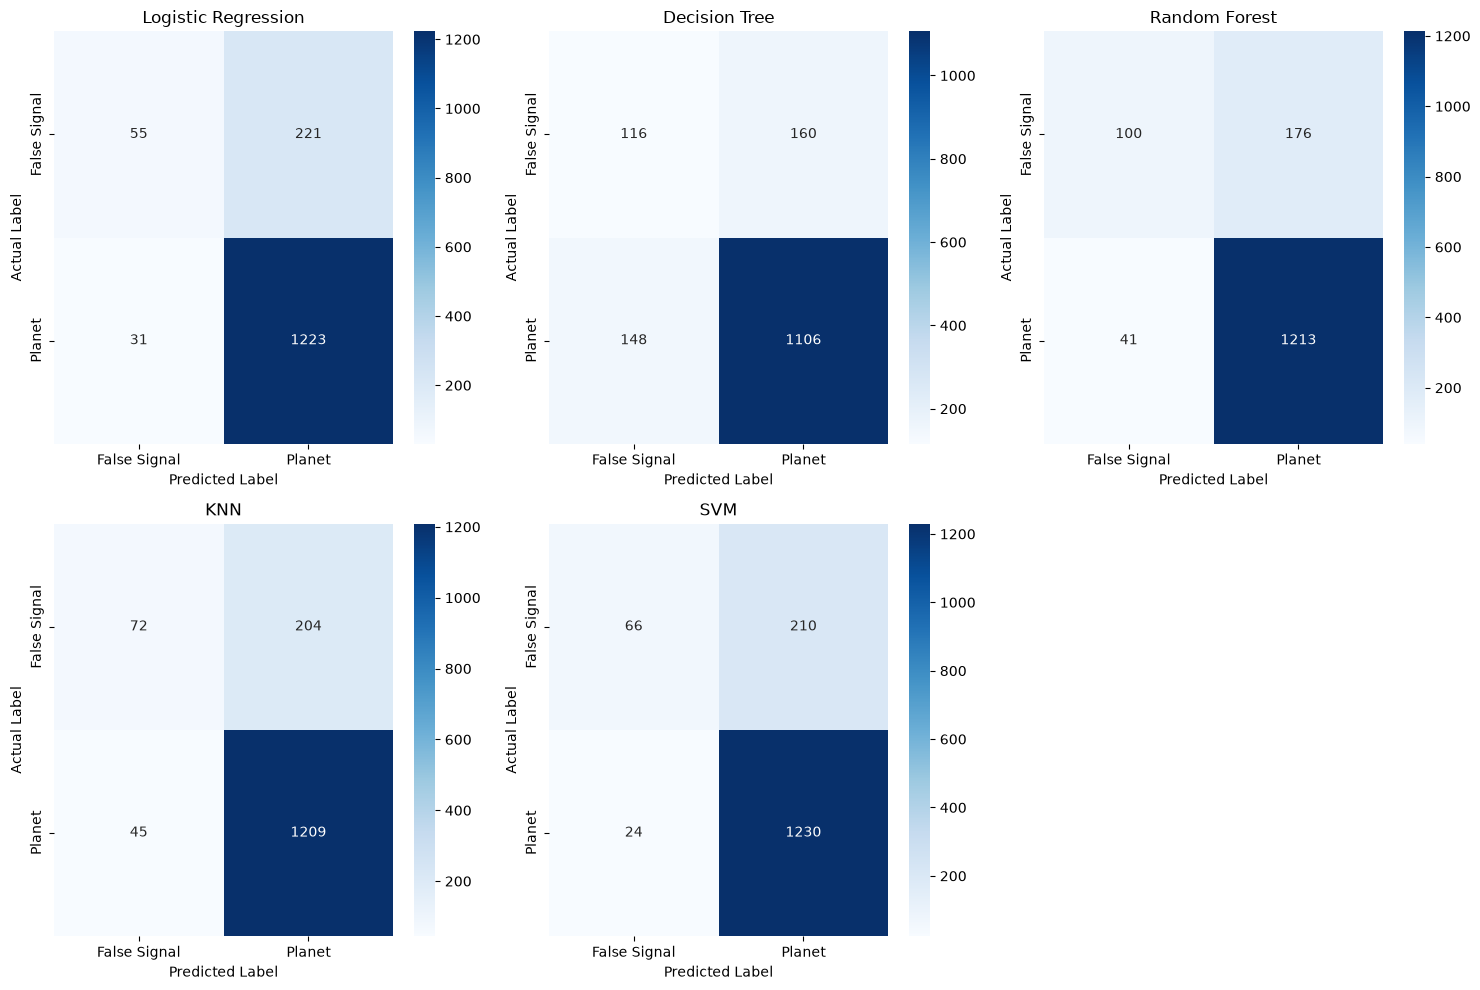

In [69]:
from sklearn.metrics import confusion_matrix

models = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "KNN": knn_pred,
    "SVM": svm_pred
}
plt.figure(figsize=(15, 10))

for i, (model_name, predictions) in enumerate(models.items(), 1):

    cm = confusion_matrix(y_test, predictions)

    plt.subplot(2, 3, i)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["False Signal", "Planet"],
        yticklabels=["False Signal", "Planet"]
    )

    plt.title(model_name)
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

#### Observation:
> The confusion matrices show that all models correctly classify most Planet cases, while some False Signal cases are misclassified as Planet. SVM shows strong classification performance with fewer misclassified Planet cases.

### Cross Validation

In [70]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    x,
    y,
    cv=5,
    scoring="f1"
)

print("Cross-validation scores:", cv_scores)
print("Mean F1 Score:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross-validation scores: [0.90850464 0.89009709 0.89621942 0.90169993 0.9078601 ]
Mean F1 Score: 0.9008762336543168
Standard Deviation: 0.007007442173451649


### Hyperparameter Tuning

In [71]:
from sklearn.model_selection import GridSearchCV
# --------------------------------------------------
# 1. Logistic Regression
# --------------------------------------------------

lr_params = {
    "C": [0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

lr_grid.fit(x_train_scaled, y_train)

print("Logistic Regression")
print("Best Parameters:", lr_grid.best_params_)
print("Best F1 Score:", lr_grid.best_score_)


# --------------------------------------------------
# 2. Decision Tree
# --------------------------------------------------

dt_params = {
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

dt_grid.fit(x_train, y_train)

print("\nDecision Tree")
print("Best Parameters:", dt_grid.best_params_)
print("Best F1 Score:", dt_grid.best_score_)


# --------------------------------------------------
# 3. Random Forest
# --------------------------------------------------

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(x_train, y_train)

print("\nRandom Forest")
print("Best Parameters:", rf_grid.best_params_)
print("Best F1 Score:", rf_grid.best_score_)


# --------------------------------------------------
# 4. KNN
# --------------------------------------------------

knn_params = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

knn_grid.fit(x_train_scaled, y_train)

print("\nKNN")
print("Best Parameters:", knn_grid.best_params_)
print("Best F1 Score:", knn_grid.best_score_)


# --------------------------------------------------
# 5. SVM
# --------------------------------------------------

svm_params = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

svm_grid = GridSearchCV(
    SVC(),
    svm_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

svm_grid.fit(x_train_scaled, y_train)

print("\nSVM")
print("Best Parameters:", svm_grid.best_params_)
print("Best F1 Score:", svm_grid.best_score_)

Logistic Regression
Best Parameters: {'C': 10, 'solver': 'liblinear'}
Best F1 Score: 0.9121821550293052

Decision Tree
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best F1 Score: 0.9114527128699876

Random Forest
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best F1 Score: 0.9221842744818225

KNN
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best F1 Score: 0.9147541917157136

SVM
Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best F1 Score: 0.9191192694054189


In [72]:
# Finding the Best Tuned Model

best_models = {
    "Logistic Regression": lr_grid.best_estimator_,
    "Decision Tree": dt_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "KNN": knn_grid.best_estimator_,
    "SVM": svm_grid.best_estimator_
}
tuned_results = []

for name, model in best_models.items():

    if name in ["Logistic Regression", "KNN", "SVM"]:
        y_pred = model.predict(x_test_scaled)
    else:
        y_pred = model.predict(x_test)

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

tuned_results_df = pd.DataFrame(tuned_results)

best_tuned_model_name = tuned_results_df.loc[
    tuned_results_df["F1 Score"].idxmax(),
    "Model"
]

print("Best Tuned Model:", best_tuned_model_name)

Best Tuned Model: Random Forest


### Observation:
>Hyperparameter tuning was performed using 5-fold cross-validation. The tuned models were evaluated on the unseen test set using accuracy, precision, recall, and F1-score. The model with the highest F1-score was selected as the final binary classification model

## SECONDARY MULTICLASS CLASSIFICATION

### Multiclass Dataset Preparation

In [73]:
multi_df = df.dropna(subset=["tfopwg_disp"]).copy()

X_multi = multi_df[x.columns].copy()

# Original multiclass target
y_multi = multi_df["tfopwg_disp"].copy()

print("Multiclass feature shape:", X_multi.shape)
print("Target shape:", y_multi.shape)

Multiclass feature shape: (7650, 15)
Target shape: (7650,)


### Train Test Split

In [74]:
from sklearn.model_selection import train_test_split

X_mtr, X_mte, y_mtr, y_mte = train_test_split(
    X_multi,
    y_multi,
    test_size=0.20,
    random_state=42,
    stratify=y_multi
)

print("Training data shape:", X_mtr.shape)
print("Testing data shape :", X_mte.shape)

Training data shape: (6120, 15)
Testing data shape : (1530, 15)


In [75]:
# Handle missing values

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_mtr_imputed = imputer.fit_transform(X_mtr)
X_mte_imputed = imputer.transform(X_mte)

print("Training data after imputation:", X_mtr_imputed.shape)
print("Testing data after imputation :", X_mte_imputed.shape)

Training data after imputation: (6120, 15)
Testing data after imputation : (1530, 15)


### Feature Scaling

In [76]:
X_mtr_scaled = scaler.fit_transform(X_mtr_imputed)
X_mte_scaled = scaler.transform(X_mte_imputed)

print("Feature scaling completed.")

Feature scaling completed.


### Training The Models.

In multiclass classification,Usage of average="macro" in precision, recall, and F1. This gives each of the six classes equal importance, which is particularly useful when the class frequencies are different.

In [77]:
# ============================
# Logistic Regression
# ============================

lr_multi = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr_multi.fit(X_mtr_scaled, y_mtr)

lr_multi_pred = lr_multi.predict(X_mte_scaled)

print("Logistic Regression")

print("Accuracy :", accuracy_score(y_mte, lr_multi_pred))
print("Precision:", precision_score(
    y_mte, lr_multi_pred,
    average="macro",
    zero_division=0
))

print("Recall   :", recall_score(
    y_mte, lr_multi_pred,
    average="macro",
    zero_division=0
))
print("F1 Score :", f1_score(
    y_mte, lr_multi_pred,
    average="macro",
    zero_division=0
))

Logistic Regression
Accuracy : 0.4869281045751634
Precision: 0.36030377957005244
Recall   : 0.4534645212587822
F1 Score : 0.3512110234900307


In [78]:
# ================================
# Decision Tree
# ================================

dt_multi = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

dt_multi.fit(X_mtr_imputed, y_mtr)

dt_multi_pred = dt_multi.predict(X_mte_imputed)

print("Decision Tree")

print("Accuracy :", accuracy_score(y_mte, dt_multi_pred))
print("Precision:", precision_score(
    y_mte, dt_multi_pred,
    average="macro",
    zero_division=0
))
print("Recall   :", recall_score(
    y_mte, dt_multi_pred,
    average="macro",
    zero_division=0
))
print("F1 Score :", f1_score(
    y_mte, dt_multi_pred,
    average="macro",
    zero_division=0
))

Decision Tree
Accuracy : 0.6379084967320261
Precision: 0.4477986464725595
Recall   : 0.4600648216652795
F1 Score : 0.45270690286727644


In [79]:
# ============================
# Random Forest
# ============================

rf_multi = RandomForestClassifier(
    n_estimators=400,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_multi.fit(X_mtr_imputed, y_mtr)

rf_multi_pred = rf_multi.predict(X_mte_imputed)

print("Random Forest")

print("Accuracy :", accuracy_score(y_mte, rf_multi_pred))
print("Precision:", precision_score(
    y_mte, rf_multi_pred,
    average="macro",
    zero_division=0
))
print("Recall   :", recall_score(
    y_mte, rf_multi_pred,
    average="macro",
    zero_division=0
))
print("F1 Score :", f1_score(
    y_mte, rf_multi_pred,
    average="macro",
    zero_division=0
))

Random Forest
Accuracy : 0.7019607843137254
Precision: 0.5409891343711426
Recall   : 0.5541684229350754
F1 Score : 0.5384262985960779


In [80]:
# =================================
# KNN
# =================================

knn_multi = KNeighborsClassifier(
    n_neighbors=5
)

knn_multi.fit(X_mtr_scaled, y_mtr)

knn_multi_pred = knn_multi.predict(X_mte_scaled)

print("KNN")

print("Accuracy :", accuracy_score(y_mte, knn_multi_pred))
print("Precision:", precision_score(
    y_mte, knn_multi_pred,
    average="macro",
    zero_division=0
))
print("Recall   :", recall_score(
    y_mte, knn_multi_pred,
    average="macro",
    zero_division=0
))
print("F1 Score :", f1_score(
    y_mte, knn_multi_pred,
    average="macro",
    zero_division=0
))

KNN
Accuracy : 0.6790849673202615
Precision: 0.4728812889842649
Recall   : 0.38689939158532516
F1 Score : 0.41604939447138334


In [81]:
# ==============================
# SVM
# ==============================

svm_multi = SVC(
    class_weight="balanced"
)

svm_multi.fit(X_mtr_scaled, y_mtr)

svm_multi_pred = svm_multi.predict(X_mte_scaled)

print("SVM")

print("Accuracy :", accuracy_score(y_mte, svm_multi_pred))
print("Precision:", precision_score(
    y_mte, svm_multi_pred,
    average="macro",
    zero_division=0
))
print("Recall   :", recall_score(
    y_mte, svm_multi_pred,
    average="macro",
    zero_division=0
))
print("F1 Score :", f1_score(
    y_mte, svm_multi_pred,
    average="macro",
    zero_division=0
))

SVM
Accuracy : 0.5718954248366013
Precision: 0.43076526194729026
Recall   : 0.5907137011881041
F1 Score : 0.448049039501124


### Model Comparison

In [82]:
multi_results = []

multi_results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_mte, lr_multi_pred),
    "Precision": precision_score(
        y_mte, lr_multi_pred,
        average="macro",
        zero_division=0
    ),
    "Recall": recall_score(
        y_mte, lr_multi_pred,
        average="macro",
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_mte, lr_multi_pred,
        average="macro",
        zero_division=0
    )
})

multi_results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_mte, dt_multi_pred),
    "Precision": precision_score(
        y_mte, dt_multi_pred,
        average="macro",
        zero_division=0
    ),
    "Recall": recall_score(
        y_mte, dt_multi_pred,
        average="macro",
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_mte, dt_multi_pred,
        average="macro",
        zero_division=0
    )
})

multi_results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_mte, rf_multi_pred),
    "Precision": precision_score(
        y_mte, rf_multi_pred,
        average="macro",
        zero_division=0
    ),
    "Recall": recall_score(
        y_mte, rf_multi_pred,
        average="macro",
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_mte, rf_multi_pred,
        average="macro",
        zero_division=0
    )
})

multi_results.append({
    "Model": "KNN",
    "Accuracy": accuracy_score(y_mte, knn_multi_pred),
    "Precision": precision_score(
        y_mte, knn_multi_pred,
        average="macro",
        zero_division=0
    ),
    "Recall": recall_score(
        y_mte, knn_multi_pred,
        average="macro",
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_mte, knn_multi_pred,
        average="macro",
        zero_division=0
    )
})

multi_results.append({
    "Model": "SVM",
    "Accuracy": accuracy_score(y_mte, svm_multi_pred),
    "Precision": precision_score(
        y_mte, svm_multi_pred,
        average="macro",
        zero_division=0
    ),
    "Recall": recall_score(
        y_mte, svm_multi_pred,
        average="macro",
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_mte, svm_multi_pred,
        average="macro",
        zero_division=0
    )
})

multi_results_df = pd.DataFrame(multi_results)

multi_results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.486928,0.360304,0.453465,0.351211
1,Decision Tree,0.637908,0.447799,0.460065,0.452707
2,Random Forest,0.701961,0.540989,0.554168,0.538426
3,KNN,0.679085,0.472881,0.386899,0.416049
4,SVM,0.571895,0.430765,0.590714,0.448049


In [83]:
# Finding the best model

best_multi_model_name = multi_results_df.loc[
    multi_results_df["F1 Score"].idxmax(),
    "Model"
]

print("Best Multiclass Model:", best_multi_model_name)

Best Multiclass Model: Random Forest


### Classification Report

In [84]:
from sklearn.metrics import classification_report

if best_multi_model_name == "Logistic Regression":
    best_multi_pred = lr_multi_pred

elif best_multi_model_name == "Decision Tree":
    best_multi_pred = dt_multi_pred

elif best_multi_model_name == "Random Forest":
    best_multi_pred = rf_multi_pred

elif best_multi_model_name == "KNN":
    best_multi_pred = knn_multi_pred

elif best_multi_model_name == "SVM":
    best_multi_pred = svm_multi_pred


print("Classification Report")
print(classification_report(
    y_mte,
    best_multi_pred,
    zero_division=0
))

Classification Report
              precision    recall  f1-score   support

          CP       0.45      0.61      0.52       150
          FA       0.30      0.15      0.20        20
          FP       0.55      0.68      0.61       256
          KP       0.56      0.59      0.57       121
          PC       0.84      0.75      0.79       983

    accuracy                           0.70      1530
   macro avg       0.54      0.55      0.54      1530
weighted avg       0.72      0.70      0.71      1530



### Confusion Matrix

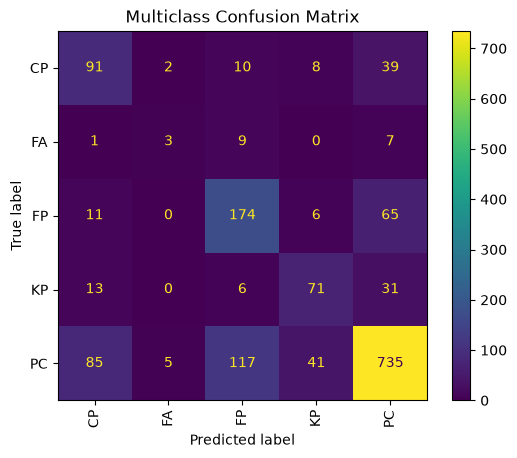

In [85]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_mte,
    best_multi_pred,
    xticks_rotation="vertical"
)

plt.title("Multiclass Confusion Matrix")
plt.show()

### Hyperparameter Tuning

In [86]:
rf_multi = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_multi_params = {
    "n_estimators": [100, 200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_multi_grid = GridSearchCV(
    rf_multi,
    rf_multi_params,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

rf_multi_grid.fit(X_mtr_imputed, y_mtr)

print("Best Parameters:")
print(rf_multi_grid.best_params_)

print("\nBest Cross-Validation Macro F1:")
print(rf_multi_grid.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation Macro F1:
0.5075826948239801


In [87]:
# prediction Using Tuned Model

best_multi_model = rf_multi_grid.best_estimator_

tuned_multi_pred = best_multi_model.predict(X_mte_imputed)

In [88]:
# Evaluate the tuned model

tuned_multi_accuracy = accuracy_score(
    y_mte,
    tuned_multi_pred
)

tuned_multi_precision = precision_score(
    y_mte,
    tuned_multi_pred,
    average="macro",
    zero_division=0
)

tuned_multi_recall = recall_score(
    y_mte,
    tuned_multi_pred,
    average="macro",
    zero_division=0
)

tuned_multi_f1 = f1_score(
    y_mte,
    tuned_multi_pred,
    average="macro",
    zero_division=0
)

print("Tuned Multiclass Model Performance")
print("-----------------------------------")
print("Accuracy :", tuned_multi_accuracy)
print("Precision:", tuned_multi_precision)
print("Recall   :", tuned_multi_recall)
print("Macro F1 :", tuned_multi_f1)

Tuned Multiclass Model Performance
-----------------------------------
Accuracy : 0.703921568627451
Precision: 0.5383910401313614
Recall   : 0.5536489248001144
Macro F1 : 0.5369250045419864


In [89]:
# Comparison before and after tuning

original_rf = multi_results_df[
    multi_results_df["Model"] == "Random Forest"
]

print("Original Random Forest:")
print(original_rf)

print("\nTuned Random Forest:")
print("Accuracy :", tuned_multi_accuracy)
print("Precision:", tuned_multi_precision)
print("Recall   :", tuned_multi_recall)
print("Macro F1 :", tuned_multi_f1)

Original Random Forest:
           Model  Accuracy  Precision    Recall  F1 Score
2  Random Forest  0.701961   0.540989  0.554168  0.538426

Tuned Random Forest:
Accuracy : 0.703921568627451
Precision: 0.5383910401313614
Recall   : 0.5536489248001144
Macro F1 : 0.5369250045419864


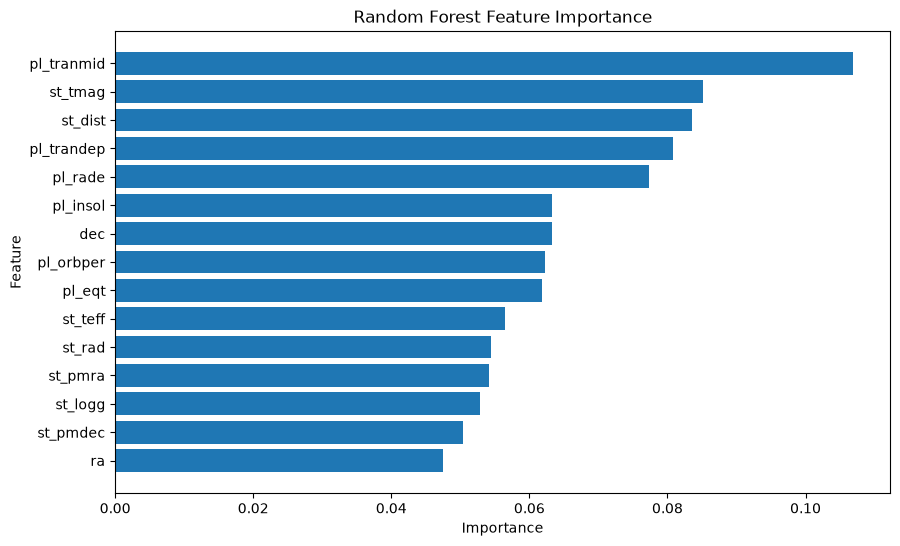

In [90]:
# feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_multi.columns,
    "Importance": best_multi_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [91]:
# ==========================================
# FINAL MODEL SAVING FOR DEPLOYMENT
# ==========================================

import joblib
import os

# Create models folder
os.makedirs("models", exist_ok=True)

# Final trained models
best_binary_model = rf_grid.best_estimator_
best_multiclass_model = rf_multi_grid.best_estimator_

# Final feature names used by the models
final_features = x.columns.tolist()

# Store models and required preprocessing information
deployment_artifacts = {
    "binary_model": best_binary_model,
    "multiclass_model": best_multiclass_model,
    "multiclass_imputer": imputer,
    "features": final_features,
    "binary_classes": {
        0: "False Signal",
        1: "Planet"
    },
    "multiclass_classes": best_multiclass_model.classes_.tolist()
}

# Save everything in one file
joblib.dump(
    deployment_artifacts,
    "models/exoplanet_best_models.pkl"
)

print("Deployment model package saved successfully.")
print("Features:", final_features)
print("Binary classes:", deployment_artifacts["binary_classes"])
print("Multiclass classes:", deployment_artifacts["multiclass_classes"])

Deployment model package saved successfully.
Features: ['ra', 'dec', 'st_pmra', 'st_pmdec', 'pl_tranmid', 'pl_orbper', 'pl_trandep', 'pl_rade', 'pl_insol', 'pl_eqt', 'st_tmag', 'st_dist', 'st_teff', 'st_logg', 'st_rad']
Binary classes: {0: 'False Signal', 1: 'Planet'}
Multiclass classes: ['CP', 'FA', 'FP', 'KP', 'PC']
